# Moran vs. Capy lambda=0 map outliers

This notebook selects the CBSA/year graphs where Moran and Capy lambda=0 disagree the most, then maps their tracts by composition amplitude: the absolute difference between each tract's black share and the CBSA/year black share, measured among black + white population.

Because Moran and Capy are on different numeric scales, `rank_gap` is the default selection criterion: the absolute gap between each graph's percentile rank under Moran and under `half_edge_lam_0_angle_1`. The raw absolute value gap is kept as `raw_gap` for reference.

In [1]:
from pathlib import Path

import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib import colors

ROOT = Path.cwd()
if not (ROOT / "outputs").exists():
    ROOT = ROOT.parent
METRICS_PATH = ROOT / "outputs/tracts_in_cbsa_2020-2010-2000-1990-1980_years_march_2020_vintage/white_black.csv"

CAPY_COLUMN = "half_edge_lam_0_angle_1"
MORAN_COLUMN = "moran"
SORT_BY = "rank_gap"
N_MAPS = 50
AMPLITUDE_CAP_QUANTILE = 0.99

plt.rcParams["figure.dpi"] = 130

## Select the CBSA/year graphs

In [2]:
metrics = pd.read_csv(METRICS_PATH)
metrics["year"] = metrics["filename"].str.extract(r"tracts_in_cbsa_\d+_(\d{4})_")[0]
metrics["cbsa"] = metrics["filename"].str.extract(r"tracts_in_cbsa_(\d+)_")[0]
metrics["capy_lam_0"] = metrics[CAPY_COLUMN]

metrics["moran_percentile"] = metrics[MORAN_COLUMN].rank(pct=True)
metrics["capy_percentile"] = metrics["capy_lam_0"].rank(pct=True)
metrics["rank_gap"] = (metrics["moran_percentile"] - metrics["capy_percentile"]).abs()
metrics["raw_gap"] = (metrics[MORAN_COLUMN] - metrics["capy_lam_0"]).abs()

selected = metrics.sort_values(SORT_BY, ascending=False).head(N_MAPS).copy()
selected["area_key"] = selected["year"] + " CBSA " + selected["cbsa"]
selected["shapefile"] = (
    selected["filename"]
    .str.replace("_connected.json", ".shp", regex=False)
    .str.replace("_orig.json", ".shp", regex=False)
    .map(lambda path: ROOT / path)
)

selected[
    [
        "area_key",
        MORAN_COLUMN,
        "capy_lam_0",
        "rank_gap",
        "raw_gap",
        "total_population",
        "total_black",
        "total_white",
        "total_nodes",
        "shapefile",
    ]
]

,area_key,moran,capy_lam_0,rank_gap,raw_gap,total_population,total_black,total_white,total_nodes,shapefile
1376,1990 CBSA 15540,0.670245,0.500553,0.685921,0.169692,177059,856,172335,38,/Users/maria/Documents/capy-bara/study_areas/1...
1196,1990 CBSA 21660,0.651266,0.501685,0.596699,0.149581,282912,2040,265391,69,/Users/maria/Documents/capy-bara/study_areas/1...
786,2000 CBSA 21660,0.608709,0.501356,0.569881,0.107353,322959,2391,286075,78,/Users/maria/Documents/capy-bara/study_areas/2...
1013,2000 CBSA 15540,0.598613,0.501495,0.547189,0.097118,198889,1426,188554,43,/Users/maria/Documents/capy-bara/study_areas/2...
1659,1980 CBSA 21660,0.596255,0.501611,0.538938,0.094644,275226,1566,261505,65,/Users/maria/Documents/capy-bara/study_areas/1...
477,2010 CBSA 21660,0.560609,0.501153,0.520371,0.059456,351715,3102,297808,86,/Users/maria/Documents/capy-bara/study_areas/2...
1511,1990 CBSA 38860,0.568424,0.501712,0.499226,0.066712,440628,2269,430929,107,/Users/maria/Documents/capy-bara/study_areas/1...
322,2020 CBSA 37100,0.666183,0.506426,0.488396,0.159757,843843,13704,360850,188,/Users/maria/Documents/capy-bara/study_areas/2...
1060,2000 CBSA 31700,0.571569,0.502266,0.482723,0.069303,380841,4493,351337,81,/Users/maria/Documents/capy-bara/study_areas/2...
481,2010 CBSA 20260,0.627411,0.504693,0.477050,0.122718,290637,3673,267639,88,/Users/maria/Documents/capy-bara/study_areas/2...


## Load map layers

In [3]:
missing = selected.loc[~selected["shapefile"].map(Path.exists), "shapefile"]
if not missing.empty:
    raise FileNotFoundError("Missing shapefiles:\n" + "\n".join(map(str, missing)))

map_layers = []
amplitude_values = []

for case in selected.itertuples():
    gdf = gpd.read_file(case.shapefile)

    white = gdf["WHITE"].astype(float)
    black = gdf["BLACK"].astype(float)
    two_group_total = black + white
    tract_black_share = black / two_group_total.replace(0, np.nan)
    cbsa_black_share = case.total_black / (case.total_black + case.total_white)
    gdf["composition_amplitude"] = (tract_black_share - cbsa_black_share).abs()
    gdf["cbsa_black_share"] = cbsa_black_share

    if gdf.crs is not None:
        try:
            gdf = gdf.to_crs(gdf.estimate_utm_crs())
        except RuntimeError:
            pass

    map_layers.append({"case": case, "gdf": gdf})
    amplitude_values.append(gdf["composition_amplitude"])

all_amplitudes = pd.concat(amplitude_values).dropna()
amplitude_cap = all_amplitudes.quantile(AMPLITUDE_CAP_QUANTILE)
if pd.isna(amplitude_cap) or amplitude_cap <= 0:
    amplitude_cap = all_amplitudes.max()

amplitude_cap

np.float64(0.4588010475588424)

## Plot composition amplitude

Composition amplitude is `abs(tract_black_share - cbsa_black_share)`, where each share is measured among black + white population. The color scale is capped at the selected quantile so a few extreme tracts do not flatten the rest of the maps.

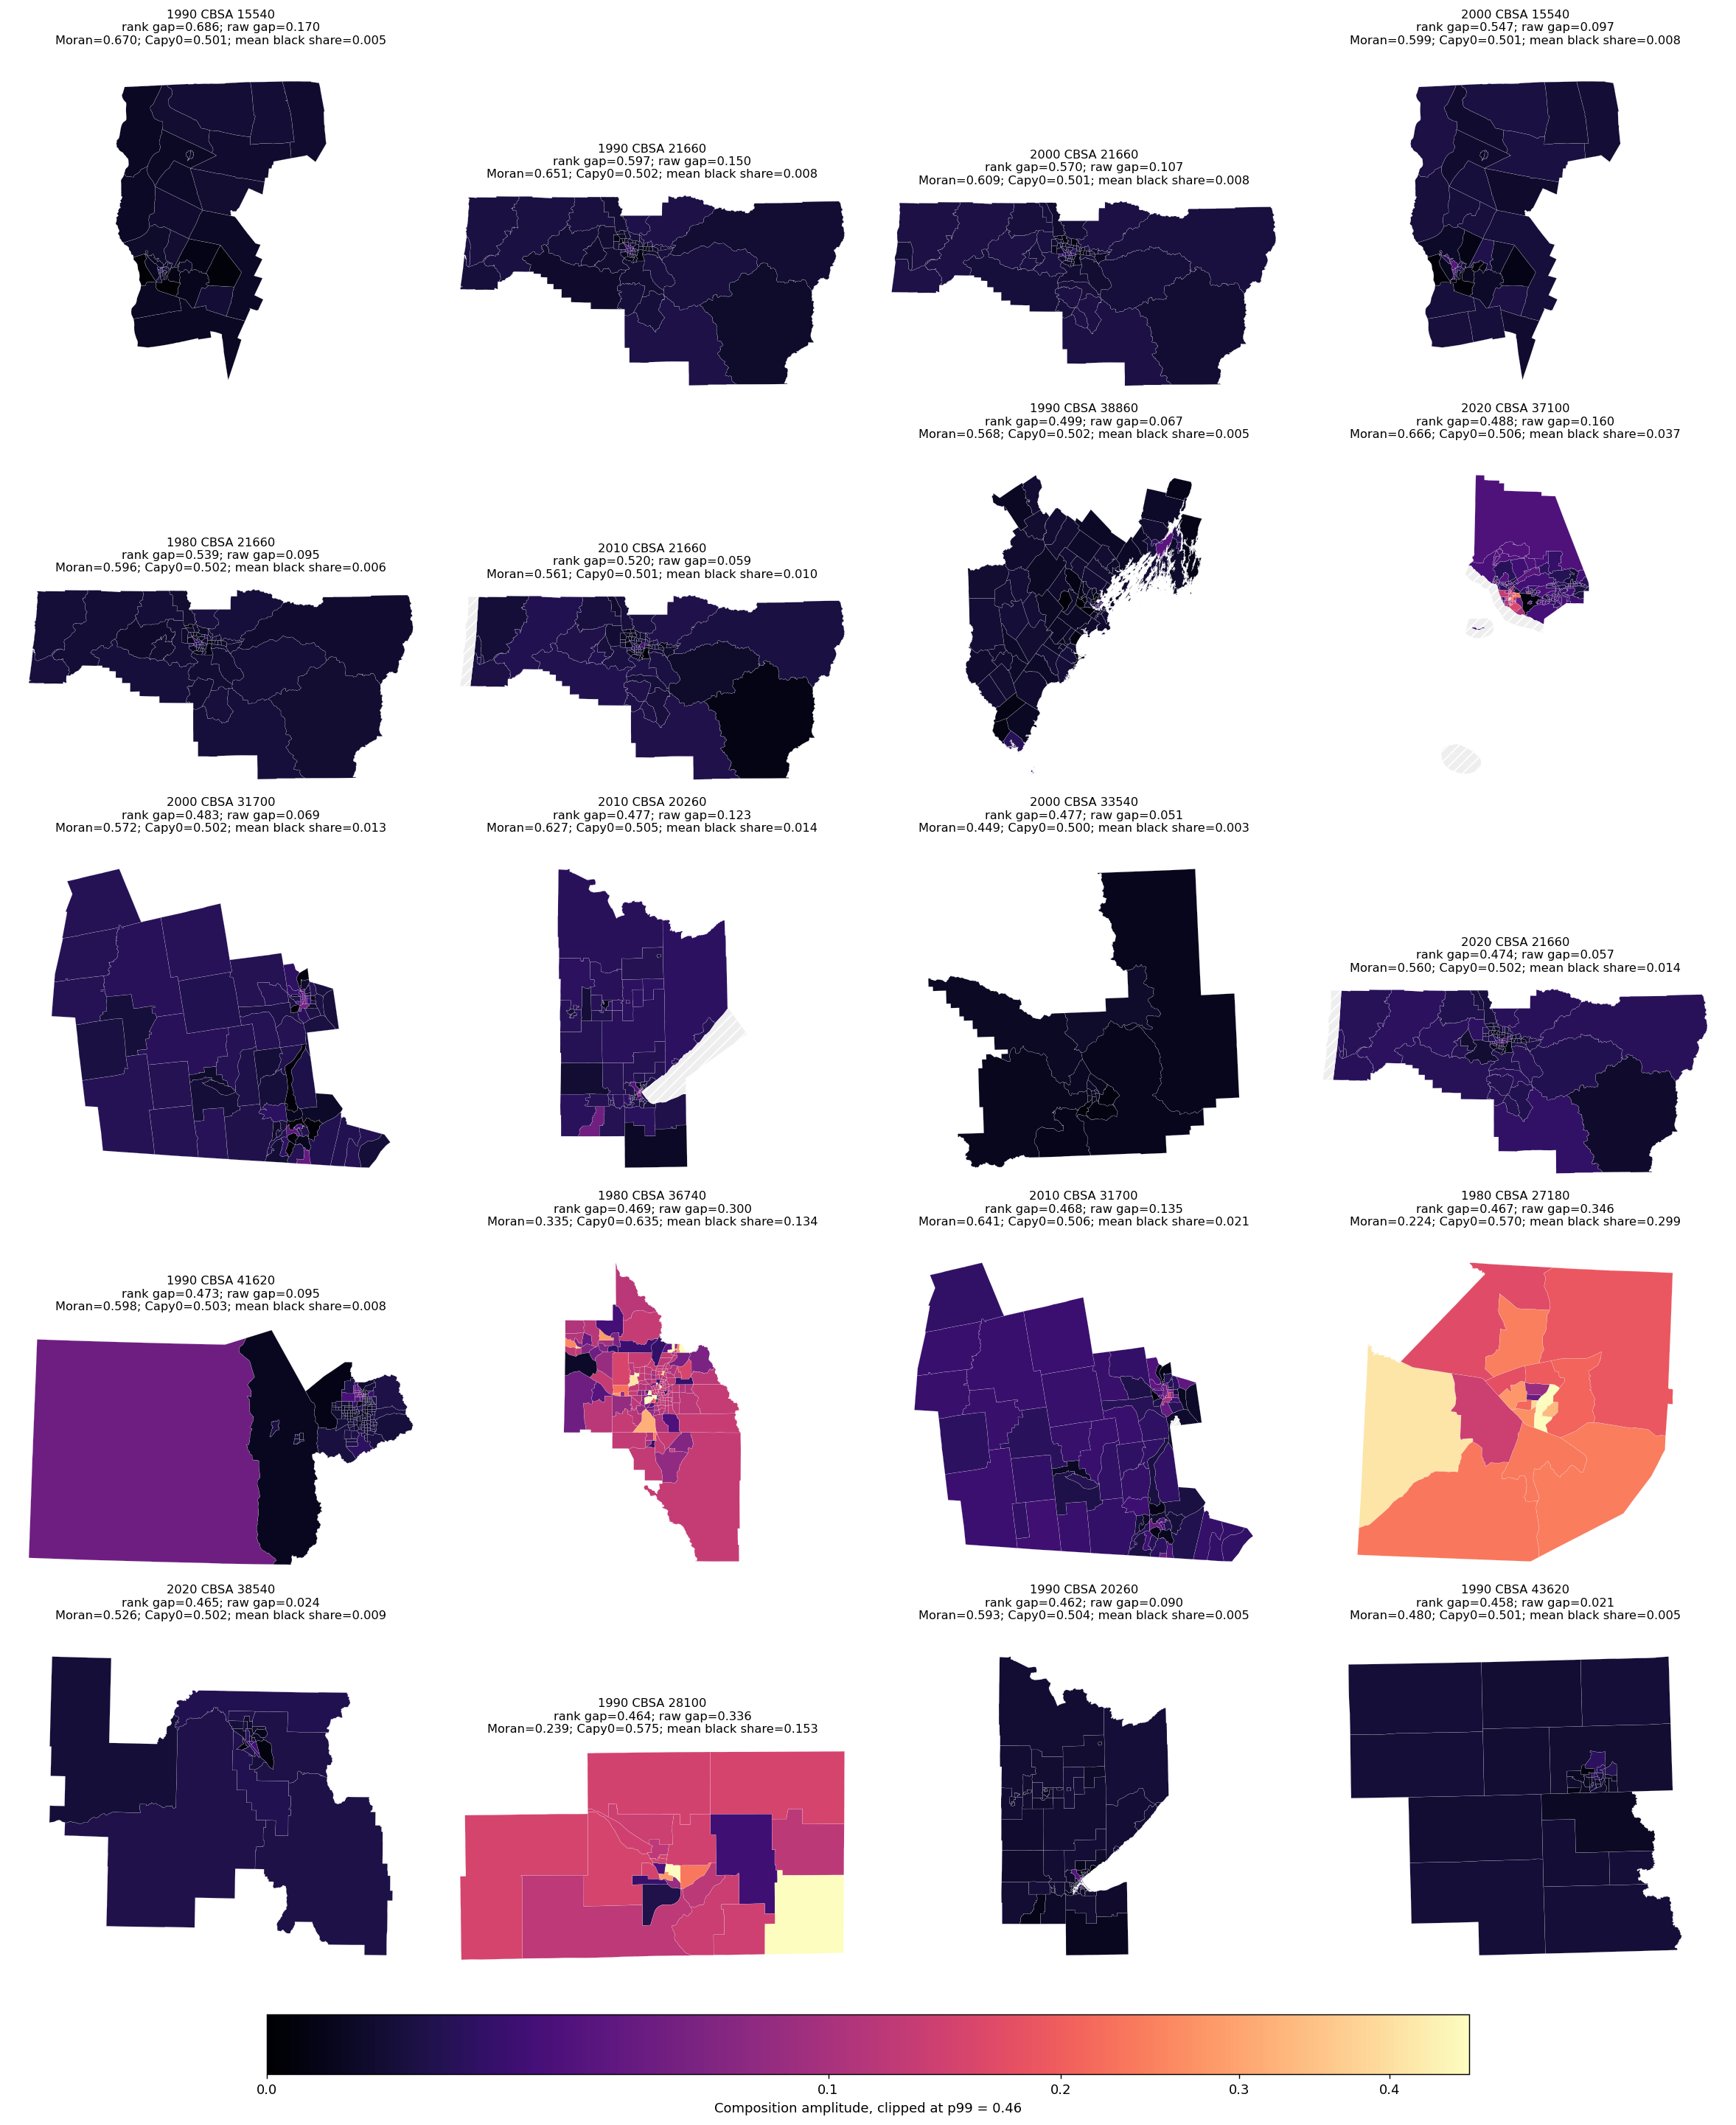

In [4]:
fig, axes = plt.subplots(5, 4, figsize=(18, 22), constrained_layout=True)
cmap = "magma"
norm = colors.PowerNorm(gamma=0.5, vmin=0, vmax=amplitude_cap)

for ax, layer in zip(axes.flat, map_layers):
    case = layer["case"]
    gdf = layer["gdf"].copy()
    gdf["amplitude_for_color"] = gdf["composition_amplitude"].clip(upper=amplitude_cap)

    gdf.plot(
        column="amplitude_for_color",
        ax=ax,
        cmap=cmap,
        norm=norm,
        linewidth=0.08,
        edgecolor="white",
        missing_kwds={"color": "#eeeeee", "edgecolor": "white", "hatch": "///"},
    )
    ax.set_title(
        f"{case.area_key}\n"
        f"rank gap={case.rank_gap:.3f}; raw gap={case.raw_gap:.3f}\n"
        f"Moran={case.moran:.3f}; Capy0={case.capy_lam_0:.3f}; mean black share={gdf['cbsa_black_share'].iloc[0]:.3f}",
        fontsize=9,
    )
    ax.set_axis_off()

for ax in axes.flat[len(map_layers):]:
    ax.set_axis_off()

sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax=axes.ravel().tolist(), location="bottom", shrink=0.7, pad=0.02)
cbar.set_label(f"Composition amplitude, clipped at p{AMPLITUDE_CAP_QUANTILE * 100:.0f} = {amplitude_cap:.2f}")